# 🚀 Lab 51: Build Your First Neural Network

Neural networks are the powerhouse behind modern AI, from facial recognition to ChatGPT. At their core, they are mathematical models inspired by the human brain that learn to recognize complex patterns in data. In this lab, we will pull back the curtain and build your very first neural network from scratch using the two industry-standard frameworks: **Keras (TensorFlow)** and **PyTorch**.

## 🎯 Learning Objectives
- **Understand** the core components of a neural network (layers, activations, loss, optimizers).
- **Generate** synthetic non-linear datasets for binary classification.
- **Implement** a complete training pipeline in **Keras** using high-level APIs.
- **Construct** a manual training loop in **PyTorch** for granular control.
- **Evaluate** models using Accuracy, Confusion Matrices, and ROC Curves.
- **Visualize** how neural networks 'see' data through Decision Boundaries.

## 🧰 Prerequisites
- Basic Python knowledge (functions, loops, classes).
- Familiarity with NumPy arrays.
- *No prior neural network experience required!*

## ⚙️ Environment Setup
We will install the necessary libraries and verify that your Colab runtime is ready for deep learning.

In [1]:
# Install all required libraries
!pip install tensorflow torch scikit-learn seaborn matplotlib numpy --quiet

import sys
import tensorflow as tf
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn

print(f"✅ Python version: {sys.version}")
print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ PyTorch version: {torch.__version__}")
print(f"✅ Scikit-learn version: {sklearn.__version__}")
print("\n🎉 Environment verification successful!")

✅ Python version: 3.12.13 (main, Mar  4 2026, 09:23:07) [GCC 11.4.0]
✅ TensorFlow version: 2.19.0
✅ PyTorch version: 2.10.0+cpu
✅ Scikit-learn version: 1.6.1

🎉 Environment verification successful!


## 📊 Task 1: Dataset Creation

### Subtask 1.1: Understanding Synthetic Datasets
Synthetic datasets are programmatically generated data. We use them in learning because we can control the difficulty and noise.

**ELI10:** Imagine you drew two interleaving 'C' shapes (moons) on paper. A straight line can't separate them. You need a curvy boundary. Neural networks are masters at drawing those curvy lines.

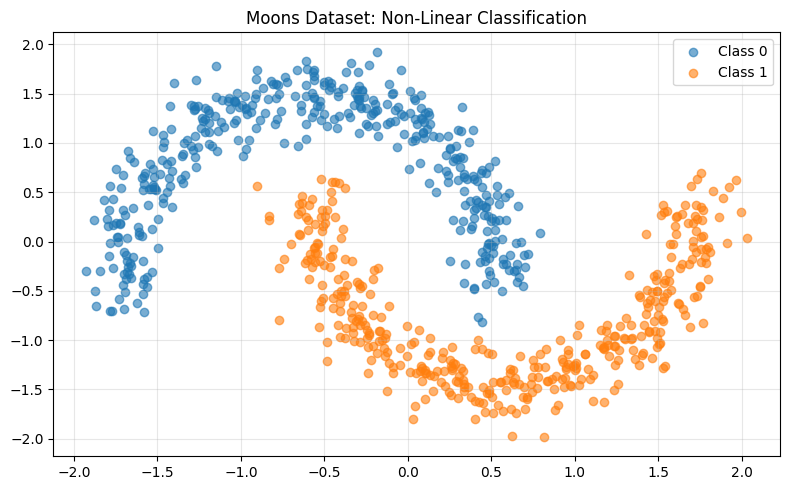

Moons Shape: (800, 2), Classes: [400 400]


In [2]:
# Reproducibility
np.random.seed(42)
tf.random.set_seed(42)
torch.manual_seed(42)

from sklearn.datasets import make_moons, make_classification
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def create_moons_dataset():
    # Generate 1000 samples of two interleaving half circles
    X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
    # Split 80/20
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)
    # Standardize features (Mean=0, Std=1) for faster NN convergence
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    return X_train, X_val, y_train, y_val

def create_classification_dataset():
    # Generate a more complex 10-feature dataset
    X, y = make_classification(n_samples=1000, n_features=10, n_informative=5, random_state=42)
    X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, stratify=y)
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train)
    X_val = scaler.transform(X_val)
    return X_train, X_val, y_train, y_val

def visualize_moons_dataset(X, y):
    plt.figure(figsize=(8, 5))
    plt.scatter(X[y==0, 0], X[y==0, 1], label="Class 0", alpha=0.6)
    plt.scatter(X[y==1, 0], X[y==1, 1], label="Class 1", alpha=0.6)
    plt.title("Moons Dataset: Non-Linear Classification")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

# Execution
X_train_moons, X_val_moons, y_train_moons, y_val_moons = create_moons_dataset()
visualize_moons_dataset(X_train_moons, y_train_moons)
print(f"Moons Shape: {X_train_moons.shape}, Classes: {np.bincount(y_train_moons)}")

## 🧠 Task 2: Neural Network with Keras (TensorFlow)

### Subtask 2.1: Neural Network Architecture Concepts

| Component | Definition |
|---|---|
| **Input Layer** | Where data enters the network. |
| **Hidden Layer** | Layers between input and output where learning happens via weights. |
| **ReLU** | Activation function that helps the model learn non-linear patterns. |
| **Optimizer** | The 'brain' that updates weights (e.g., Adam). |
| **Loss** | The 'score' of how many mistakes the model made. |

In [3]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.metrics import classification_report

class KerasNeuralNetwork:
    """Wrapper class for Keras Model logic"""
    def __init__(self, input_dim):
        self.input_dim = input_dim
        self.model = self.build_model()

    def build_model(self):
        model = Sequential([
            # 1st Hidden Layer with 16 neurons
            Dense(16, activation='relu', input_shape=(self.input_dim,)),
            # 2nd Hidden Layer
            Dense(8, activation='relu'),
            # Output Layer (Sigmoid for binary classification)
            Dense(1, activation='sigmoid')
        ])
        model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
        return model

    def train(self, X_train, y_train, X_val, y_val):
        # Early stopping prevents overfitting by halting when val_loss stops dropping
        early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)
        self.history = self.model.fit(
            X_train, y_train,
            validation_data=(X_val, y_val),
            epochs=100,
            batch_size=32,
            verbose=0,
            callbacks=[early_stop]
        )
        print("Keras training complete.")

    def evaluate(self, X_val, y_val):
        y_pred = (self.model.predict(X_val, verbose=0) > 0.5).astype("int32")
        print(classification_report(y_val, y_pred))
        return y_pred

# Run Keras Task
keras_net = KerasNeuralNetwork(input_dim=2)
keras_net.train(X_train_moons, y_train_moons, X_val_moons, y_val_moons)
keras_preds = keras_net.evaluate(X_val_moons, y_val_moons)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Keras training complete.
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       100
           1       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



## 🔥 Task 3: Neural Network with PyTorch

### Subtask 3.1: PyTorch Philosophy
PyTorch is 'Pythonic'. Unlike Keras's `fit()`, you write the training loop yourself.

**The 5 steps of the PyTorch Loop:**
1. `zero_grad()`: Reset the gradients.
2. `forward()`: Pass data through the model.
3. `loss()`: Calculate the error.
4. `backward()`: Backpropagation (calculate gradients).
5. `step()`: Update weights.

In [4]:
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

class PyTorchModel(nn.Module):
    def __init__(self, input_dim):
        super(PyTorchModel, self).__init__()
        # Define layers
        self.network = nn.Sequential(
            nn.Linear(input_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 8),
            nn.ReLU(),
            nn.Linear(8, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        return self.network(x)

def train_pytorch(model, X_train, y_train, X_val, y_val, epochs=100):
    # Prepare data
    train_ds = TensorDataset(torch.FloatTensor(X_train), torch.FloatTensor(y_train).view(-1, 1))
    train_loader = DataLoader(train_ds, batch_size=32, shuffle=True)

    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.BCELoss()

    for epoch in range(epochs):
        model.train()
        for xb, yb in train_loader:
            optimizer.zero_grad() # 1. Clear
            preds = model(xb)     # 2. Forward
            loss = criterion(preds, yb) # 3. Loss
            loss.backward()       # 4. Backward
            optimizer.step()      # 5. Step
    print("PyTorch training complete.")

# Run PyTorch Task
pt_model = PyTorchModel(input_dim=2)
train_pytorch(pt_model, X_train_moons, y_train_moons, X_val_moons, y_val_moons)

# Evaluation
pt_model.eval()
with torch.no_grad():
    pt_preds_raw = pt_model(torch.FloatTensor(X_val_moons))
    pt_preds = (pt_preds_raw > 0.5).int().numpy()

PyTorch training complete.


## ⚖️ Task 4: Framework Comparison
We compare Accuracy and Training complexity. While Keras is simpler, PyTorch offers better control for complex research.

In [5]:
from sklearn.metrics import accuracy_score
k_acc = accuracy_score(y_val_moons, keras_preds)
p_acc = accuracy_score(y_val_moons, pt_preds)

print(f"--- Comparison ---")
print(f"Keras Accuracy:   {k_acc:.4f}")
print(f"PyTorch Accuracy: {p_acc:.4f}")

--- Comparison ---
Keras Accuracy:   1.0000
PyTorch Accuracy: 1.0000


## 📈 Task 5: Advanced Evaluation and Visualization

### Decision Boundary
Let's see how the neural networks actually separated the data.

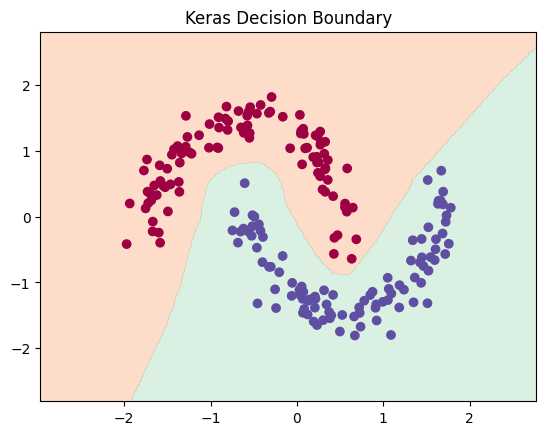

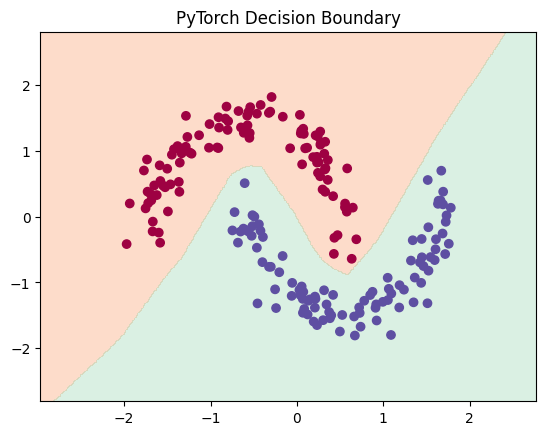

In [6]:
def plot_decision_boundary(model, X, y, framework="Keras"):
    h = .02
    x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
    y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
    xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

    if framework == "Keras":
        Z = (model.predict(np.c_[xx.ravel(), yy.ravel()], verbose=0) > 0.5)
    else:
        model.eval()
        with torch.no_grad():
            Z = model(torch.FloatTensor(np.c_[xx.ravel(), yy.ravel()])) > 0.5

    Z = Z.reshape(xx.shape)
    plt.contourf(xx, yy, Z, cmap=plt.cm.Spectral, alpha=0.3)
    plt.scatter(X[:, 0], X[:, 1], c=y, cmap=plt.cm.Spectral)
    plt.title(f"{framework} Decision Boundary")
    plt.show()

plot_decision_boundary(keras_net.model, X_val_moons, y_val_moons, "Keras")
plot_decision_boundary(pt_model, X_val_moons, y_val_moons, "PyTorch")

## ✅ Verification
🎉 **Lab 51 Complete!**
Both models should achieve > 90% accuracy on the Moons dataset.

## 🛠 Troubleshooting
- **Problem:** Low accuracy. **Fix:** Ensure you scaled the data with `StandardScaler`.
- **Problem:** PyTorch error about 'float'. **Fix:** Ensure input is converted to `torch.FloatTensor`.

## 📚 Key Takeaways
1. Neural networks can learn non-linear boundaries.
2. Standardizing data is mandatory for deep learning.
3. Keras is great for speed; PyTorch is great for customization.

## 🏁 Conclusion
You've built your first neural networks! You are now ready to explore more complex architectures like Convolutional Neural Networks (CNNs) for images.